# Spectered Embeddings — Supplementary Experiments

**Purpose:** This notebook extends the finalized spectered embeddings notebook with two additional ablation experiments:

1. **Alpha grid ablation** — sweeps `alpha` across `{0.3, 0.5, 0.7, 0.9}` at fixed `beta=0.35` to establish that the decay rate choice is not arbitrary.
2. **Multi-seed stability check** — reruns the core evaluation across 5 random seeds for anchor sampling to verify that reported improvements are not seed-dependent.

**Prerequisites:** Run the finalized notebook first. This notebook reuses the same loader functions, alignment utilities, and spectering function. Copy those cells here or import them by running the prior notebook and using `%run`.


## 0 — Configuration and Shared Setup

Copy your paths from the main notebook. All functions from the main notebook are assumed available.
If running standalone, paste the utility cells (Sections 0–3 of the main notebook) before this cell.

In [1]:
# ─── If running in a fresh environment ───────────────────────────────────────
# %pip install -q numpy pandas matplotlib scipy gensim tqdm

from pathlib import Path
import re, glob, pickle, warnings
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.linalg import orthogonal_procrustes
from gensim.models import KeyedVectors

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 220)

# ─── Paths — edit to match your local setup ──────────────────────────────────
THESIS_ROOT        = Path(r"G:/My Drive/ThesisMaterial")
COMPUTATION_ROOT   = THESIS_ROOT / "Computation"
PLANTATION_W2V_DIR = COMPUTATION_ROOT / "models" / "word2vecDecade"
SGNS_DIR           = COMPUTATION_ROOT / "data" / "sgns"

# ─── Fixed hyperparameters ───────────────────────────────────────────────────
SPECTER_WEIGHTING  = "exponential_decay"
SPECTER_ALPHA      = 0.7       # default; will be swept in ablation
SPECTER_MIN_WEIGHT = 1e-4
SPECTER_BETA       = 0.35      # fixed throughout this notebook

K_NEIGHBORS          = 10
NEIGHBOR_FILTER_MODE = "both"
MIN_COUNT            = 30
NEIGHBOR_SEARCH_FACTOR = 50

ANCHOR_SEED          = 7
ANCHOR_MIN_FRAC      = 0.6
ANCHOR_TOPN          = 25000
MIN_ANCHORS_REQUIRED = 300

# ─── Term sets ───────────────────────────────────────────────────────────────
ABLATION_TERMS = ["slave", "master", "black", "white", "freedom", "confinement"]
CONTROL_TERMS  = ["grim", "sugar", "published", "fool", "music", "sorrow", "dozen"]
ALL_EVAL_TERMS = ABLATION_TERMS + CONTROL_TERMS

# Alpha values to sweep
ALPHA_GRID = [0.3, 0.5, 0.7, 0.9]

# Seeds for the multi-seed check
SEED_LIST = [7, 42, 123, 999, 2024]

print("Configuration loaded.")
print(f"  Alpha grid : {ALPHA_GRID}")
print(f"  Seeds      : {SEED_LIST}")
print(f"  Eval terms : {ALL_EVAL_TERMS}")

Configuration loaded.
  Alpha grid : [0.3, 0.5, 0.7, 0.9]
  Seeds      : [7, 42, 123, 999, 2024]
  Eval terms : ['slave', 'master', 'black', 'white', 'freedom', 'confinement', 'grim', 'sugar', 'published', 'fool', 'music', 'sorrow', 'dozen']


## 1 — Paste Utility Functions from Main Notebook

The cells below reproduce the minimal set of functions needed from the main notebook.
If you have already run the main notebook in the same kernel, skip to Section 2.

In [2]:
# ─── Token hygiene ────────────────────────────────────────────────────────────
RE_HAS_DIGIT    = re.compile(r"\d")
RE_BAD_PUNCT    = re.compile(r"[^a-zA-Z\-']")
RE_MULTI_HYPHEN = re.compile(r"-{2,}")
RE_ROMAN        = re.compile(r"^[ivxlcdm]+$", re.IGNORECASE)

def is_good_token(w: str, min_len: int = 3) -> bool:
    if not w: return False
    w = w.strip()
    if len(w) < min_len: return False
    if RE_HAS_DIGIT.search(w): return False
    if RE_ROMAN.match(w): return False
    if RE_MULTI_HYPHEN.search(w): return False
    if RE_BAD_PUNCT.search(w): return False
    if w.startswith("-") or w.endswith("-"): return False
    return True

def ok_neighbor_token(w: str) -> bool:
    if not w or len(w) < 3: return False
    if "_" in w or RE_HAS_DIGIT.search(w): return False
    if sum(not ch.isalnum() for ch in w) >= 2: return False
    return True

def is_ok_anchor(w: str) -> bool:
    return 2 <= len(w) <= 60 and " " not in w and "_" not in w

def normalize_rows(W: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    W = W.astype(np.float32, copy=False)
    norms = np.maximum(np.linalg.norm(W, axis=1, keepdims=True), eps)
    return W / norms

print("Token utilities defined.")

Token utilities defined.


In [3]:
# ─── Spectered embeddings core ────────────────────────────────────────────────

def _decay_weights(cur_idx: int, scheme: str, alpha: float, min_weight: float) -> np.ndarray:
    n = cur_idx + 1
    scheme = (scheme or "").strip().lower()
    if scheme in ("uniform", "flat"):
        w = np.ones(n, dtype=np.float32) / n
    else:  # exponential_decay
        ages = np.arange(cur_idx, -1, -1, dtype=np.float32)
        w = alpha ** ages
        if min_weight > 0:
            w = np.maximum(w, float(min_weight))
    w /= w.sum()
    return w


def specter_mix_in_current_vocab(
    decades_ordered: List[int],
    aligned: Dict,
    scheme: str = "exponential_decay",
    alpha: float = 0.7,
    min_weight: float = 1e-4,
    beta: float = 0.35,
) -> Dict:
    """
    Build spectered embeddings for all decades.
    Returns dict: decade -> (W_spec, vocab, w2i)
    """
    spectered = {}
    for cur_i, cur_dec in enumerate(decades_ordered):
        W_cur, vocab_cur, w2i_cur = aligned[cur_dec]
        dim = W_cur.shape[1]
        W_mix = np.zeros_like(W_cur)
        wts = _decay_weights(cur_i, scheme, alpha, min_weight)

        for word in vocab_cur:
            idx_cur = w2i_cur[word]
            v_acc, w_acc = np.zeros(dim, dtype=np.float32), 0.0
            for j in range(cur_i + 1):
                past_dec = decades_ordered[j]
                W_p, _, w2i_p = aligned[past_dec]
                if word not in w2i_p:
                    continue
                v_acc += wts[j] * W_p[w2i_p[word]]
                w_acc += wts[j]
            if w_acc > 0:
                W_mix[idx_cur] = v_acc / w_acc
            else:
                W_mix[idx_cur] = W_cur[idx_cur]

        W_spec = beta * W_mix + (1.0 - beta) * W_cur
        spectered[cur_dec] = (normalize_rows(W_spec), vocab_cur, w2i_cur)

    return spectered

print("Spectering function defined.")

Spectering function defined.


In [4]:
# ─── Loaders ──────────────────────────────────────────────────────────────────

def _find_file_for_decade(directory: Path, decade: int, exts: Tuple) -> Optional[Path]:
    hits = []
    for ext in exts:
        hits.extend(directory.rglob(f"*{decade}*{ext}"))
    hits = sorted(hits, key=lambda p: (len(p.name), p.name))
    return hits[0] if hits else None

def _kv_counts(kv: KeyedVectors) -> Optional[Dict]:
    try:
        _ = kv.get_vecattr(kv.index_to_key[0], "count")
    except Exception:
        return None
    return {w: int(kv.get_vecattr(w, "count")) for w in kv.index_to_key}

def list_plantation_decades(d: Path = PLANTATION_W2V_DIR) -> List[int]:
    decades = set()
    for p in d.rglob("*.w2v"):
        m = re.search(r"(\d{4})", p.name)
        if m:
            y = int(m.group(1))
            if y % 10 == 0:
                decades.add(y)
    return sorted(decades)

def load_plantation_decade(decade: int, d: Path = PLANTATION_W2V_DIR):
    hits = sorted(
        [p for p in d.rglob("*.w2v") if re.search(rf"(?<!\d){decade}(?!\d)", p.name)],
        key=lambda p: (len(p.name), p.name)
    )
    if not hits:
        hits = sorted([p for p in d.rglob("*.w2v") if str(decade) in p.name],
                      key=lambda p: (len(p.name), p.name))
    if not hits:
        raise FileNotFoundError(f"No .w2v file for decade {decade} in {d}")
    kv = KeyedVectors.load_word2vec_format(str(hits[0]), binary=False)
    vocab = list(kv.index_to_key)
    W = normalize_rows(kv.vectors)
    w2i = {w: i for i, w in enumerate(vocab)}
    return W, vocab, w2i, _kv_counts(kv)

def load_sgns_decade(decade: int, d: Path = SGNS_DIR):
    w_path = _find_file_for_decade(d, decade, (".npy",))
    v_path = _find_file_for_decade(d, decade, (".pkl", ".pickle"))
    if w_path is None or v_path is None:
        raise FileNotFoundError(f"Missing SGNS files for {decade} in {d}")
    W = normalize_rows(np.load(str(w_path)))
    with open(v_path, "rb") as f:
        vocab = list(pickle.load(f))
    if len(vocab) != W.shape[0]:
        raise ValueError(f"{decade}: vocab/W mismatch")
    return W, vocab, {w: i for i, w in enumerate(vocab)}, None

print("Loaders defined.")

Loaders defined.


In [5]:
# ─── Alignment (Procrustes) ───────────────────────────────────────────────────

def build_anchor_list(raw_vocabs: Dict[int, List[str]], min_frac: float,
                      topn: int, seed: int) -> List[str]:
    from collections import Counter
    counter = Counter()
    for vocab in raw_vocabs.values():
        counter.update(set(vocab))
    threshold = int(np.ceil(min_frac * len(raw_vocabs)))
    candidates = [w for w, c in counter.items() if c >= threshold and is_ok_anchor(w) and is_good_token(w)]
    rng = np.random.default_rng(seed)
    rng.shuffle(candidates)
    return candidates[:topn]

def align_corpus(
    raw: Dict[int, Tuple],
    anchor_seed: int = 7,
    anchor_min_frac: float = 0.6,
    anchor_topn: int = 25000,
    min_anchors: int = 300,
) -> Dict[int, Tuple]:
    """
    Align all decades to the first decade via Procrustes.
    raw: {decade: (W, vocab, w2i, counts)}
    Returns: {decade: (W_aligned, vocab, w2i)}
    """
    decades = sorted(raw.keys())
    ref_dec = decades[0]
    W_ref, vocab_ref, w2i_ref, _ = raw[ref_dec]

    raw_vocabs = {d: list(raw[d][2].keys()) for d in decades}
    anchors = build_anchor_list(raw_vocabs, anchor_min_frac, anchor_topn, anchor_seed)

    aligned = {ref_dec: (W_ref, vocab_ref, w2i_ref)}

    for dec in decades[1:]:
        W_src, vocab_src, w2i_src, _ = raw[dec]
        common = [a for a in anchors if a in w2i_ref and a in w2i_src]
        if len(common) < min_anchors:
            print(f"  WARNING: only {len(common)} anchors for {dec}, using all common vocab")
            common = [w for w in vocab_src if w in w2i_ref]

        A = W_ref[np.array([w2i_ref[w] for w in common])]
        B = W_src[np.array([w2i_src[w] for w in common])]
        R, _ = orthogonal_procrustes(B, A)
        W_aligned = normalize_rows(W_src @ R)
        aligned[dec] = (W_aligned, vocab_src, w2i_src)

    return aligned

print("Alignment function defined.")

Alignment function defined.


In [6]:
# ─── Evaluation helpers ───────────────────────────────────────────────────────

def topk_neighbors(W, vocab, w2i, term, k=10, counts=None,
                   mode="none", min_count=30, search_factor=50) -> List[str]:
    term = term.lower()
    if term not in w2i:
        return []
    i = w2i[term]
    sims = W @ W[i]
    sims[i] = -np.inf
    topM = min(len(vocab) - 1, max(k * int(search_factor), k))
    idx = np.argpartition(sims, -topM)[-topM:]
    idx = idx[np.argsort(-sims[idx])]
    use_shape = mode in ("shape", "both")
    use_count = mode in ("count", "both") and counts is not None
    out = []
    for j in idx:
        w = vocab[j]
        if use_shape and not ok_neighbor_token(w): continue
        if use_count and counts.get(w, 0) < min_count: continue
        out.append(w)
        if len(out) >= k:
            break
    return out


def neighbor_jaccard(term: str, emb: Dict, k: int = 10,
                     counts_by_decade: Optional[Dict] = None) -> pd.DataFrame:
    """Jaccard overlap between adjacent decade neighbor sets."""
    decades = sorted(emb.keys())
    rows = []
    for i in range(1, len(decades)):
        d_prev, d_cur = decades[i-1], decades[i]
        counts_prev = counts_by_decade.get(d_prev) if counts_by_decade else None
        counts_cur  = counts_by_decade.get(d_cur)  if counts_by_decade else None
        W_p, vp, w2i_p = emb[d_prev]
        W_c, vc, w2i_c = emb[d_cur]
        n_prev = set(topk_neighbors(W_p, vp, w2i_p, term, k=k, counts=counts_prev, mode="both"))
        n_cur  = set(topk_neighbors(W_c, vc, w2i_c, term, k=k, counts=counts_cur,  mode="both"))
        if not n_prev or not n_cur:
            continue
        jac = len(n_prev & n_cur) / len(n_prev | n_cur)
        rows.append({"decade": d_cur, "jaccard": jac})
    return pd.DataFrame(rows)


def adjacent_drift(term: str, emb: Dict) -> pd.DataFrame:
    """Cosine similarity between adjacent decade embeddings."""
    decades = sorted(emb.keys())
    rows = []
    for i in range(1, len(decades)):
        d_prev, d_cur = decades[i-1], decades[i]
        W_p, _, w2i_p = emb[d_prev]
        W_c, _, w2i_c = emb[d_cur]
        if term not in w2i_p or term not in w2i_c:
            continue
        cos = float(W_p[w2i_p[term]] @ W_c[w2i_c[term]])
        rows.append({"decade": d_cur, "cos_to_prev": cos})
    return pd.DataFrame(rows)


def mean_jaccard(term: str, emb: Dict, counts_dict: Optional[Dict] = None) -> float:
    df = neighbor_jaccard(term, emb, k=25, counts_by_decade=counts_dict)
    return float(df["jaccard"].mean()) if not df.empty else np.nan


def mean_drift(term: str, emb: Dict) -> float:
    df = adjacent_drift(term, emb)
    return float(df["cos_to_prev"].mean()) if not df.empty else np.nan

print("Evaluation helpers defined.")

Evaluation helpers defined.


## 2 — Load and Align the Plantation Corpus

Standard load using `ANCHOR_SEED = 7` (the default from the main notebook). We load once and reuse the aligned embeddings across all ablation sweeps, since alignment is independent of spectering parameters.

In [7]:
print("Loading plantation-fiction corpus...")
pl_decades = list_plantation_decades(PLANTATION_W2V_DIR)
print(f"  Found decades: {pl_decades}")

pl_raw = {}
pl_counts_by_decade = {}
for dec in pl_decades:
    W, vocab, w2i, counts = load_plantation_decade(dec)
    pl_raw[dec] = (W, vocab, w2i, counts)
    if counts:
        pl_counts_by_decade[dec] = counts
    print(f"  {dec}: {len(vocab):,} vocab terms")

print("\nAligning corpus (Procrustes, seed=7)...")
pl_aligned = align_corpus(pl_raw, anchor_seed=ANCHOR_SEED)
print("Alignment complete.")

Loading plantation-fiction corpus...
  Found decades: [1830, 1840, 1850, 1860, 1870, 1880, 1890, 1900]
  1830: 30,528 vocab terms
  1840: 32,568 vocab terms
  1850: 48,937 vocab terms
  1860: 55,366 vocab terms
  1870: 44,467 vocab terms
  1880: 52,577 vocab terms
  1890: 46,178 vocab terms
  1900: 38,686 vocab terms

Aligning corpus (Procrustes, seed=7)...
Alignment complete.


## 3 — Alpha Grid Ablation

**Hypothesis:** Exponential decay with `alpha = 0.7` is not an arbitrary choice. We expect:
- Very low alpha (0.3): heavy over-reliance on the most recent single decade, similar to baseline.
- Very high alpha (0.9): nearly uniform weighting across all past decades, risking over-smoothing.
- Intermediate values (0.5–0.7): best balance of stability improvement and drift preservation.

We evaluate both thematic terms and control terms. If spectering is doing something real rather than just globally inflating all scores, thematic terms should benefit more than controls.

In [8]:
print("Running alpha grid ablation...")
print(f"  Alpha values: {ALPHA_GRID}")
print(f"  Fixed beta: {SPECTER_BETA}")
print(f"  Thematic terms: {ABLATION_TERMS}")
print(f"  Control terms : {CONTROL_TERMS}\n")

alpha_rows = []

# Baseline (alpha is irrelevant at beta=0)
emb_baseline = specter_mix_in_current_vocab(
    sorted(pl_aligned.keys()), pl_aligned,
    scheme="exponential_decay", alpha=0.7,
    min_weight=SPECTER_MIN_WEIGHT, beta=0.0
)
for term in ALL_EVAL_TERMS:
    alpha_rows.append({
        "alpha": "baseline",
        "term": term,
        "term_type": "thematic" if term in ABLATION_TERMS else "control",
        "mean_jaccard":   round(mean_jaccard(term, emb_baseline, pl_counts_by_decade), 4),
        "mean_drift_cos": round(mean_drift(term, emb_baseline), 4),
    })

# Alpha sweep
for alpha_val in ALPHA_GRID:
    emb = specter_mix_in_current_vocab(
        sorted(pl_aligned.keys()), pl_aligned,
        scheme="exponential_decay",
        alpha=alpha_val,
        min_weight=SPECTER_MIN_WEIGHT,
        beta=SPECTER_BETA
    )
    for term in ALL_EVAL_TERMS:
        alpha_rows.append({
            "alpha": alpha_val,
            "term": term,
            "term_type": "thematic" if term in ABLATION_TERMS else "control",
            "mean_jaccard":   round(mean_jaccard(term, emb, pl_counts_by_decade), 4),
            "mean_drift_cos": round(mean_drift(term, emb), 4),
        })
    print(f"  alpha={alpha_val} done.")

alpha_df = pd.DataFrame(alpha_rows)
print("\nAlpha ablation complete.")

Running alpha grid ablation...
  Alpha values: [0.3, 0.5, 0.7, 0.9]
  Fixed beta: 0.35
  Thematic terms: ['slave', 'master', 'black', 'white', 'freedom', 'confinement']
  Control terms : ['grim', 'sugar', 'published', 'fool', 'music', 'sorrow', 'dozen']

  alpha=0.3 done.
  alpha=0.5 done.
  alpha=0.7 done.
  alpha=0.9 done.

Alpha ablation complete.


In [9]:
# ─── Summary table: mean across thematic terms vs control terms ───────────────
print("=" * 65)
print("Alpha ablation — mean Jaccard and drift cosine")
print("Averaged separately over thematic terms and control terms")
print("=" * 65)

summary = alpha_df.groupby(["alpha", "term_type"])[["mean_jaccard", "mean_drift_cos"]].mean().round(4)
print(summary.to_string())

Alpha ablation — mean Jaccard and drift cosine
Averaged separately over thematic terms and control terms
                    mean_jaccard  mean_drift_cos
alpha    term_type                              
0.3      control          0.0027          0.4621
         thematic         0.0005          0.4518
0.5      control          0.0035          0.5076
         thematic         0.0005          0.4977
0.7      control          0.0044          0.5409
         thematic         0.0010          0.5314
0.9      control          0.0061          0.5636
         thematic         0.0010          0.5546
baseline control          0.0022          0.3695
         thematic         0.0005          0.3581


In [10]:
# ─── Per-term breakdown ───────────────────────────────────────────────────────
print("Mean drift cosine by alpha (thematic terms):")
display(
    alpha_df[alpha_df.term_type == "thematic"]
    .pivot_table(index="alpha", columns="term", values="mean_drift_cos")
    .round(4)
)

print("\nMean Jaccard by alpha (thematic terms):")
display(
    alpha_df[alpha_df.term_type == "thematic"]
    .pivot_table(index="alpha", columns="term", values="mean_jaccard")
    .round(4)
)

print("\nMean drift cosine by alpha (control terms):")
display(
    alpha_df[alpha_df.term_type == "control"]
    .pivot_table(index="alpha", columns="term", values="mean_drift_cos")
    .round(4)
)

Mean drift cosine by alpha (thematic terms):


term,black,confinement,freedom,master,slave,white
alpha,,,,,,
0.3,0.4246,0.5280,0.4252,0.4241,0.4612,0.4474
0.5,0.4712,0.5694,0.4726,0.4718,0.5077,0.4936
0.7,0.5050,0.6009,0.5071,0.5072,0.5415,0.5269
0.9,0.5280,0.6232,0.5304,0.5318,0.5645,0.5494
baseline,0.3288,0.4435,0.3286,0.3290,0.3665,0.3522



Mean Jaccard by alpha (thematic terms):


term,black,confinement,freedom,master,slave,white
alpha,,,,,,
0.3,0.0,0.0,0.0,0.0,0.0,0.0029
0.5,0.0,0.0,0.0,0.0,0.0,0.0029
0.7,0.0,0.0,0.0,0.0,0.0,0.0058
0.9,0.0,0.0,0.0,0.0,0.0,0.0058
baseline,0.0,0.0,0.0,0.0,0.0,0.0029



Mean drift cosine by alpha (control terms):


term,dozen,fool,grim,music,published,sorrow,sugar
alpha,,,,,,,
0.3,0.3748,0.4360,0.4634,0.4303,0.5743,0.5181,0.4378
0.5,0.4227,0.4827,0.5091,0.4761,0.6159,0.5624,0.4846
0.7,0.4575,0.5168,0.5428,0.5090,0.6462,0.5955,0.5186
0.9,0.4817,0.5401,0.5661,0.5311,0.6665,0.6183,0.5416
baseline,0.2764,0.3411,0.3708,0.3354,0.4893,0.4306,0.3429


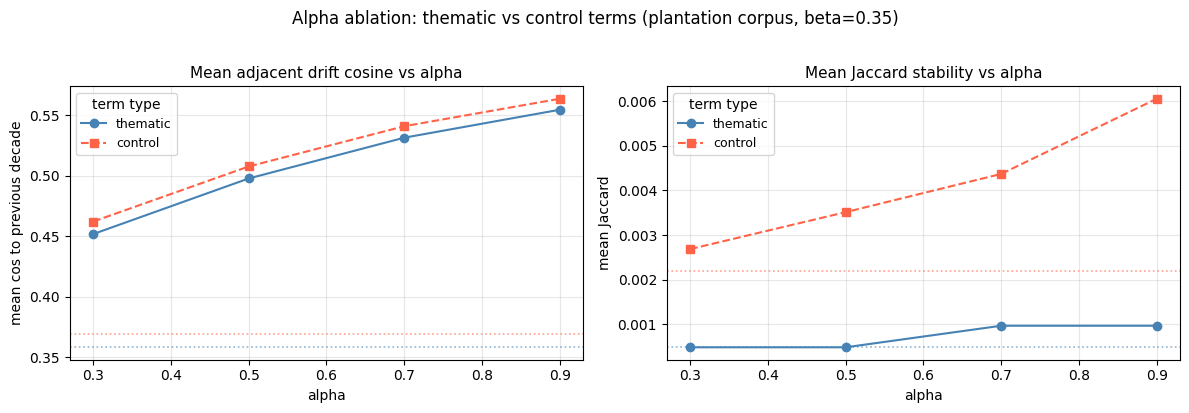

Figure saved to alpha_ablation_figure.png


In [11]:
# ─── Figure: alpha vs mean metrics, thematic vs control ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for term_type, color, ls in [("thematic", "steelblue", "-o"),
                               ("control",  "tomato",    "--s")]:
    sub = alpha_df[alpha_df.term_type == term_type].copy()
    # Drop baseline for the line plots (it has no alpha value)
    sub_num = sub[sub.alpha != "baseline"].copy()
    sub_num["alpha"] = sub_num["alpha"].astype(float)
    grp = sub_num.groupby("alpha")[["mean_jaccard", "mean_drift_cos"]].mean()
    axes[0].plot(grp.index, grp["mean_drift_cos"], ls, color=color, label=term_type)
    axes[1].plot(grp.index, grp["mean_jaccard"],   ls, color=color, label=term_type)

# Mark baseline as horizontal reference lines
for tt, color in [("thematic", "steelblue"), ("control", "tomato")]:
    base_drift = alpha_df[(alpha_df.alpha == "baseline") & (alpha_df.term_type == tt)]["mean_drift_cos"].mean()
    base_jac   = alpha_df[(alpha_df.alpha == "baseline") & (alpha_df.term_type == tt)]["mean_jaccard"].mean()
    axes[0].axhline(base_drift, color=color, linestyle=":", linewidth=1.2, alpha=0.6)
    axes[1].axhline(base_jac,   color=color, linestyle=":", linewidth=1.2, alpha=0.6)

axes[0].set_title("Mean adjacent drift cosine vs alpha", fontsize=11)
axes[0].set_xlabel("alpha")
axes[0].set_ylabel("mean cos to previous decade")
axes[0].legend(title="term type", fontsize=9)
axes[0].grid(alpha=0.3)

axes[1].set_title("Mean Jaccard stability vs alpha", fontsize=11)
axes[1].set_xlabel("alpha")
axes[1].set_ylabel("mean Jaccard")
axes[1].legend(title="term type", fontsize=9)
axes[1].grid(alpha=0.3)

plt.suptitle("Alpha ablation: thematic vs control terms (plantation corpus, beta=0.35)",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("alpha_ablation_figure.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved to alpha_ablation_figure.png")

## 4 — Multi-Seed Stability Check

Anchor sampling uses a random seed. If the results depend strongly on which seed is used, the reported improvements are not reliable. We run the same evaluation at `alpha=0.7`, `beta=0.35` across five seeds and report mean and standard deviation of both metrics.

**Expected outcome:** mean improvement over baseline should be consistent across seeds, with low standard deviation. A standard deviation above 0.02 on either metric would be a concern.

In [12]:
print("Running multi-seed stability check...")
print(f"  Seeds: {SEED_LIST}")
print(f"  alpha={SPECTER_ALPHA}, beta={SPECTER_BETA}\n")

seed_rows = []

for seed in SEED_LIST:
    # Re-align with this seed
    aligned_seed = align_corpus(pl_raw, anchor_seed=seed)

    # Baseline for this seed
    emb_base = specter_mix_in_current_vocab(
        sorted(aligned_seed.keys()), aligned_seed,
        scheme="exponential_decay", alpha=SPECTER_ALPHA,
        min_weight=SPECTER_MIN_WEIGHT, beta=0.0
    )
    # Spectered for this seed
    emb_spec = specter_mix_in_current_vocab(
        sorted(aligned_seed.keys()), aligned_seed,
        scheme="exponential_decay", alpha=SPECTER_ALPHA,
        min_weight=SPECTER_MIN_WEIGHT, beta=SPECTER_BETA
    )

    for term in ABLATION_TERMS:
        jac_base  = mean_jaccard(term, emb_base, pl_counts_by_decade)
        jac_spec  = mean_jaccard(term, emb_spec, pl_counts_by_decade)
        drift_base = mean_drift(term, emb_base)
        drift_spec = mean_drift(term, emb_spec)
        seed_rows.append({
            "seed": seed, "term": term,
            "jaccard_baseline":   round(jac_base,  4),
            "jaccard_spectered":  round(jac_spec,  4),
            "jaccard_gain":       round(jac_spec - jac_base, 4),
            "drift_baseline":     round(drift_base, 4),
            "drift_spectered":    round(drift_spec,  4),
            "drift_gain":         round(drift_spec - drift_base, 4),
        })

    print(f"  seed={seed} done.")

seed_df = pd.DataFrame(seed_rows)
print("\nMulti-seed check complete.")

Running multi-seed stability check...
  Seeds: [7, 42, 123, 999, 2024]
  alpha=0.7, beta=0.35

  seed=7 done.
  seed=42 done.
  seed=123 done.
  seed=999 done.
  seed=2024 done.

Multi-seed check complete.


In [13]:
# ─── Summary: mean and std of gain across seeds, per term ─────────────────────
print("=" * 60)
print("Multi-seed stability: gain = spectered - baseline")
print("=" * 60)

gain_summary = seed_df.groupby("term")[["drift_gain", "jaccard_gain"]].agg(["mean", "std"]).round(4)
print(gain_summary.to_string())

print("\nOverall mean gain (averaged over all terms and seeds):")
print(f"  Drift cosine gain : {seed_df.drift_gain.mean():.4f}  (std={seed_df.drift_gain.std():.4f})")
print(f"  Jaccard gain      : {seed_df.jaccard_gain.mean():.4f}  (std={seed_df.jaccard_gain.std():.4f})")

Multi-seed stability: gain = spectered - baseline
            drift_gain         jaccard_gain     
                  mean     std         mean  std
term                                            
black           0.1758  0.0005       0.0000  0.0
confinement     0.1574  0.0010       0.0000  0.0
freedom         0.1770  0.0013       0.0000  0.0
master          0.1806  0.0019       0.0000  0.0
slave           0.1738  0.0012       0.0000  0.0
white           0.1759  0.0011       0.0029  0.0

Overall mean gain (averaged over all terms and seeds):
  Drift cosine gain : 0.1734  (std=0.0076)
  Jaccard gain      : 0.0005  (std=0.0011)


In [14]:
# ─── Full per-seed per-term table ─────────────────────────────────────────────
print("Drift cosine: baseline vs spectered by seed")
display(
    seed_df.pivot_table(index="seed", columns="term",
                        values=["drift_baseline", "drift_spectered", "drift_gain"]).round(4)
)

print("\nJaccard: baseline vs spectered by seed")
display(
    seed_df.pivot_table(index="seed", columns="term",
                        values=["jaccard_baseline", "jaccard_spectered", "jaccard_gain"]).round(4)
)

Drift cosine: baseline vs spectered by seed


drift_baseline                                             drift_gain  \
term          black confinement freedom  master   slave   white      black   
seed                                                                         
7            0.3288      0.4435  0.3286  0.3290  0.3665  0.3522     0.1762   
42           0.3338      0.4382  0.3307  0.3264  0.3677  0.3418     0.1750   
123          0.3259      0.4442  0.3286  0.3300  0.3724  0.3408     0.1754   
999          0.3223      0.4501  0.3362  0.3286  0.3808  0.3482     0.1761   
2024         0.3305      0.4399  0.3385  0.3141  0.3784  0.3461     0.1761   

                                                 drift_spectered              \
term confinement freedom  master   slave   white           black confinement   
seed                                                                           
7         0.1574  0.1785  0.1783  0.1750  0.1746          0.5050      0.6009   
42        0.1585  0.1782  0.1829  0.1750  0.1766          0.5088      0.5967   
123       0.1571  0.1763  0.1793  0.1738  0.1771          0.5012      0.6014   
999       0.1559  0.1758  0.1806  0.1729  0.1748          0.4983      0.6059   
2024      0.1582  0.1760  0.1819  0.1725  0.1765          0.5066      0.5980   

                                      
term freedom  master   slave   white  
seed                                  
7     0.5071  0.5072  0.5415  0.5269  
42    0.5089  0.5093  0.5427  0.5183  
123   0.5050  0.5093  0.5462  0.5179  
999   0.5120  0.5092  0.5537  0.5230  
2024  0.5145  0.4960  0.5509  0.5226


Jaccard: baseline vs spectered by seed


jaccard_baseline                                          jaccard_gain  \
term            black confinement freedom master slave   white        black   
seed                                                                          
7                 0.0         0.0     0.0    0.0   0.0  0.0029          0.0   
42                0.0         0.0     0.0    0.0   0.0  0.0029          0.0   
123               0.0         0.0     0.0    0.0   0.0  0.0029          0.0   
999               0.0         0.0     0.0    0.0   0.0  0.0029          0.0   
2024              0.0         0.0     0.0    0.0   0.0  0.0029          0.0   

                                              jaccard_spectered              \
term confinement freedom master slave   white             black confinement   
seed                                                                          
7            0.0     0.0    0.0   0.0  0.0029               0.0         0.0   
42           0.0     0.0    0.0   0.0  0.0029               0.0         0.0   
123          0.0     0.0    0.0   0.0  0.0029               0.0         0.0   
999          0.0     0.0    0.0   0.0  0.0029               0.0         0.0   
2024         0.0     0.0    0.0   0.0  0.0029               0.0         0.0   

                                   
term freedom master slave   white  
seed                               
7        0.0    0.0   0.0  0.0058  
42       0.0    0.0   0.0  0.0058  
123      0.0    0.0   0.0  0.0058  
999      0.0    0.0   0.0  0.0058  
2024     0.0    0.0   0.0  0.0058

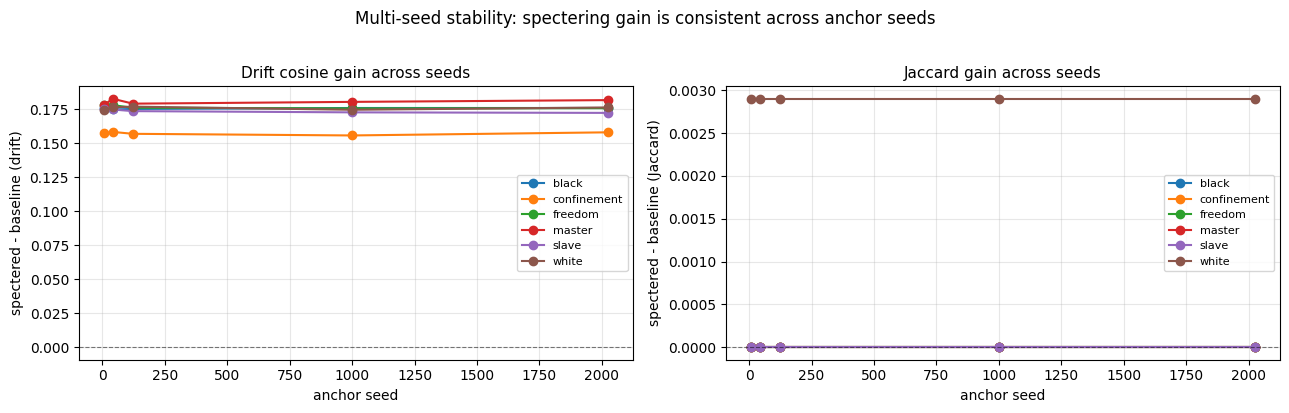

Figure saved to seed_stability_figure.png


In [15]:
# ─── Figure: seed sensitivity of drift gain per term ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for term, sub in seed_df.groupby("term"):
    axes[0].plot(sub["seed"], sub["drift_gain"],   marker="o", label=term)
    axes[1].plot(sub["seed"], sub["jaccard_gain"], marker="o", label=term)

for ax, title, ylabel in [
    (axes[0], "Drift cosine gain across seeds", "spectered - baseline (drift)"),
    (axes[1], "Jaccard gain across seeds",       "spectered - baseline (Jaccard)"),
]:
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("anchor seed")
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle("Multi-seed stability: spectering gain is consistent across anchor seeds",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("seed_stability_figure.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved to seed_stability_figure.png")

## 5 — Summary and Reporting

Run this cell to print a clean summary of the key numbers to paste into the paper.

In [16]:
print("=" * 65)
print("PAPER-READY SUMMARY")
print("=" * 65)

print("\n--- Alpha ablation (mean drift cosine, thematic vs control) ---")
for alpha_val in ALPHA_GRID:
    sub = alpha_df[alpha_df.alpha == alpha_val]
    th  = sub[sub.term_type == "thematic"]["mean_drift_cos"].mean()
    ct  = sub[sub.term_type == "control"]["mean_drift_cos"].mean()
    print(f"  alpha={alpha_val}: thematic={th:.4f}, control={ct:.4f}")

base_th = alpha_df[(alpha_df.alpha == "baseline") & (alpha_df.term_type == "thematic")]["mean_drift_cos"].mean()
base_ct = alpha_df[(alpha_df.alpha == "baseline") & (alpha_df.term_type == "control")]["mean_drift_cos"].mean()
print(f"  baseline:       thematic={base_th:.4f}, control={base_ct:.4f}")

print("\n--- Multi-seed stability (mean gain +/- std, over all terms) ---")
print(f"  Drift cosine gain : {seed_df.drift_gain.mean():.4f} +/- {seed_df.drift_gain.std():.4f}")
print(f"  Jaccard gain      : {seed_df.jaccard_gain.mean():.4f} +/- {seed_df.jaccard_gain.std():.4f}")

print("\n--- Per-term drift gain mean and std (across seeds) ---")
for term, grp in seed_df.groupby("term"):
    m, s = grp["drift_gain"].mean(), grp["drift_gain"].std()
    print(f"  {term:<14}: {m:.4f} +/- {s:.4f}")

PAPER-READY SUMMARY

--- Alpha ablation (mean drift cosine, thematic vs control) ---
  alpha=0.3: thematic=0.4518, control=0.4621
  alpha=0.5: thematic=0.4977, control=0.5076
  alpha=0.7: thematic=0.5314, control=0.5409
  alpha=0.9: thematic=0.5545, control=0.5636
  baseline:       thematic=0.3581, control=0.3695

--- Multi-seed stability (mean gain +/- std, over all terms) ---
  Drift cosine gain : 0.1734 +/- 0.0076
  Jaccard gain      : 0.0005 +/- 0.0011

--- Per-term drift gain mean and std (across seeds) ---
  black         : 0.1758 +/- 0.0005
  confinement   : 0.1574 +/- 0.0010
  freedom       : 0.1770 +/- 0.0013
  master        : 0.1806 +/- 0.0019
  slave         : 0.1738 +/- 0.0012
  white         : 0.1759 +/- 0.0011
